In [1]:
from datetime import datetime,timedelta
from matplotlib import pyplot as plt
import numpy as np
import os
from datetime import datetime,timezone

In [2]:
from file_finder import find_files_in_range
from side_config import find_calib_files_for_datafile
from sql import sql_writer
from sql import get_values_in_timerange

from mossbauer import mossbauer

from raw import epix 
from L0 import L0Driver
from L1 import L1BMDriver
from L2P import L2ParaDriver
from S2 import L2SpectrumDriver


## Data File

In [26]:
tend=datetime.now()- timedelta(hours=30)
tstart=tend- timedelta(days=9) - timedelta(hours=14)

files=find_files_in_range('/data/share',tstart,tend)
#print(files)

In [27]:
files = [file for file in files if file.split(".")[-1]!='1']
files = [file for file in files if file.split(".")[-1]!='46']
files = files[:-1]
len(files)
#files = [file for file in files if file.split(".")[-1]!='2']

204

In [28]:
det=mossbauer(files[0])

In [29]:
det.read_first_time()

datetime.datetime(2026, 3, 21, 19, 34, 2, 802360)

In [30]:
np.mean(np.load('/data/gain/filter.npy'))

np.float64(0.8976754853219697)

In [31]:

data_selector= np.zeros((44,192))
start=2
end=47
up=2
down=43
data_selector[up:down,start:end]=1
data_selector[up:down,start+48:end+48]=1
data_selector[up:down,48*2+start:48*2+end]=1
data_selector[up:down,48*3+start:48*3+end]=1

In [32]:
eff= np.load('/data/dark/filter.npy') * np.load('/data/gain/filter.npy')
fff= np.zeros( np.shape(eff))
efs=[]

for i in range(4):
    fff[up*4:down*4,start*4+ 192*i : end*4 + 192*i ] =1 
    efs.append( np.mean(eff[up*4:down*4,start*4+ 192*i : end*4 + 192*i ]  )  )

In [33]:
efs

[np.float64(0.9222222222222223),
 np.float64(0.9350609756097561),
 np.float64(0.9601964769647696),
 np.float64(0.9018631436314363)]

In [34]:
ds=[]
for i in range(4):
    dss= np.zeros((44,192))
    dss[up:down,start+48*i:end+48*i]=1
    ds.append(dss) 

In [35]:
det= mossbauer(files[0])
np.shape(det.load_data())

(7200, 44, 192)

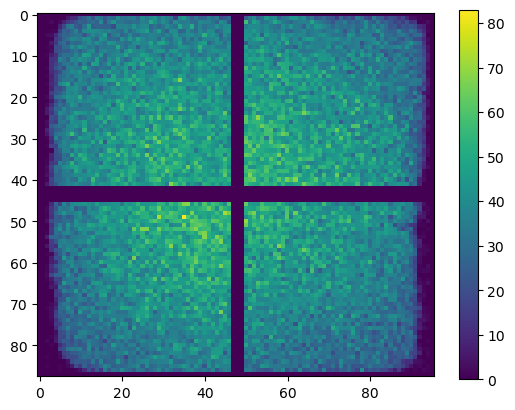

In [36]:
# Get a sample frame; 
frame=4
plt.imshow(mossbauer.convert_image(data_selector*det.get_img(frame)))
plt.colorbar()
plt.savefig("demo_quadrant")
plt.show()

In [37]:
from tqdm import tqdm
fc=np.empty((1,4))
bc=np.empty((1,4))


for file in tqdm(files):
    det=mossbauer(file)
    dat=det.load_data()
    nframes=np.shape(dat)[0]
    
    t_counts=np.zeros((nframes,4))
    for i in range(nframes):
        for j in range(4):
            t_counts[i,j]=np.sum(dat[i]*ds[j])
    
    findex= np.where( det.get_word(6)==1)[0]
    bindex= np.where( det.get_word(6)==0)[0]

    fc=np.concatenate((fc,t_counts[findex]),axis=0)
    bc=np.concatenate((bc,t_counts[bindex]),axis=0)

    #print(file, np.max(t_counts[findex]))

fc= fc[1:]
bc= bc[1:]

100%|██████████| 204/204 [01:06<00:00,  3.09it/s]


In [38]:
np.shape(bc)

(733439, 4)

In [39]:
np.std(fc[1:,3])
for i in range(4):
    print(np.mean(fc[1:,i]))

66832.33498355685
62053.29742336073
68758.81172726727
67578.9786825299


缩放后参数:
a_fit = 71778.33666034328
b_fit = -0.13963718269477013

原始 x 下的参数:
a_real = 71778.33666034328
b_real = -1.903871665972722e-07
R² = 0.30471919070052567


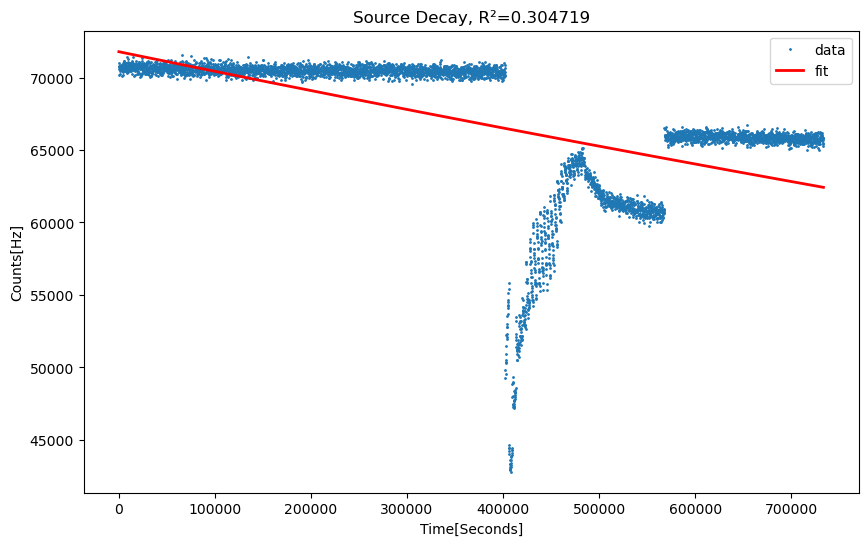

In [40]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# 指数函数：无常数项
def exp_func(x, a, b):
    return a * np.exp(b * x)

# 你的数据
y = np.array(bc[:,0], dtype=np.float64)
x = np.arange(len(y), dtype=np.float64)

# 去掉异常值
mask = np.isfinite(x) & np.isfinite(y)
x = x[mask]
y = y[mask]

# 缩放 x，避免数值溢出
x_min = x.min()
x_max = x.max()
scale = x_max - x_min
x_scaled = (x - x_min) / scale

# 初值
p0 = [y.max(), -1.0]

# 拟合
popt, pcov = curve_fit(
    exp_func,
    x_scaled,
    y,
    p0=p0,
    maxfev=20000
)

a_fit, b_fit = popt

# 恢复到原始 x 的 b
b_real = b_fit / scale
a_real = a_fit * np.exp(-b_fit * x_min / scale)

print("缩放后参数:")
print("a_fit =", a_fit)
print("b_fit =", b_fit)

print("\n原始 x 下的参数:")
print("a_real =", a_real)
print("b_real =", b_real)

# 拟合值
y_fit = exp_func(x_scaled, *popt)

# R²
ss_res = np.sum((y - y_fit) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - ss_res / ss_tot
print("R² =", r2)

# 画图抽样
idx = np.linspace(0, len(x) - 1, 5000, dtype=int)

plt.figure(figsize=(10, 6))
plt.plot(x[idx], y[idx], '.', ms=2, label='data')
plt.plot(x[idx], y_fit[idx], 'r-', lw=2, label='fit')
plt.xlabel('Time[Seconds]')
plt.ylabel('Counts[Hz]')
plt.legend()
plt.title(f'Source Decay, R²={r2:.6f}')
plt.savefig("Source_Decay")
plt.show()

In [41]:
y_fit[0]

np.float64(71778.33666034328)

In [19]:
y_fit[-1]

np.float64(62499.16575786362)

In [20]:
x[-1]

np.float64(733438.0)

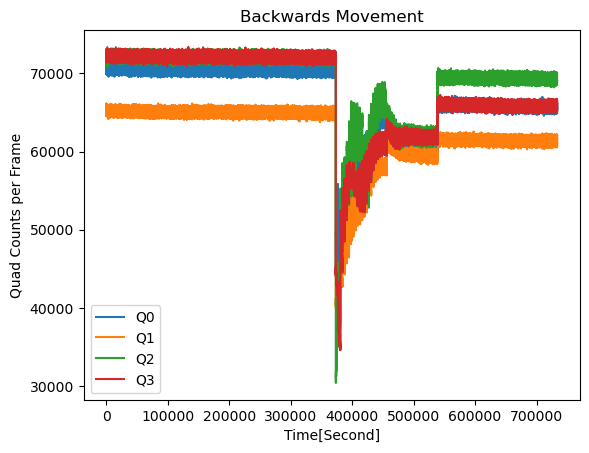

In [21]:
plt.title("Backwards Movement")
plt.plot(bc[:,0],label='Q0')
plt.plot(bc[:,1],label='Q1')
plt.plot(bc[:,2],label='Q2')
plt.plot(bc[:,3],label='Q3')
plt.xlabel("Time[Second]")
plt.ylabel("Quad Counts per Frame")
plt.legend()
plt.savefig("Frame_Count_Time")
plt.show()

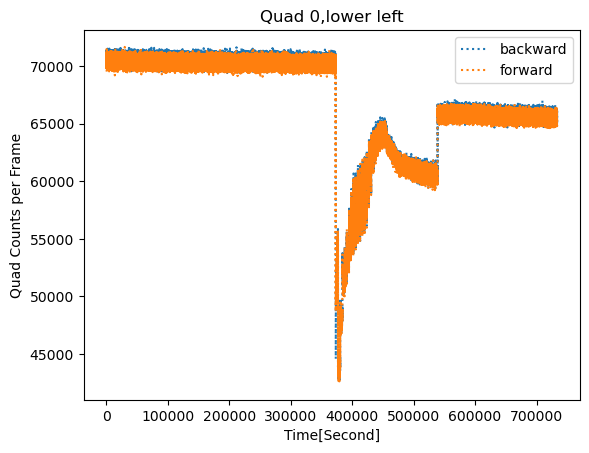

In [22]:
plt.plot(bc[:,0],':',label='backward')
plt.plot(fc[:,0],':',label="forward")
plt.title("Quad 0,lower left")
plt.xlabel("Time[Second]")
plt.ylabel("Quad Counts per Frame")
plt.legend()
plt.savefig('Q0_bc_plot')

In [23]:
len(bc[:,0])

733439

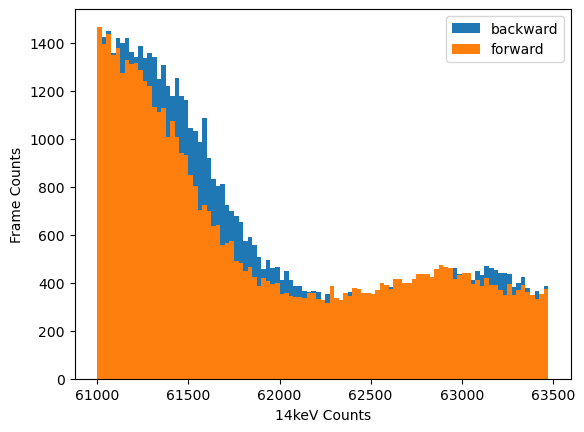

In [24]:
hist= np.arange(0,2500,25) + 61000

plt.hist(bc[:,0],bins=hist,label='backward')
plt.hist(fc[:,0],bins=hist,label='forward')
plt.xlabel("14keV Counts")
plt.ylabel("Frame Counts")
plt.legend()
plt.savefig('Q0_hist')
plt.show()

In [25]:
n = len(fc)//600 
stda = np.empty((n,4))

for i in range(n):
    stda[i]= np.std(fc[:600*i,:]-bc[:600*i,:] ,axis=0  )/np.sqrt(i*600)

/home/analysis/anaconda3/lib/python3.13/site-packages/numpy/_core/_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/analysis/anaconda3/lib/python3.13/site-packages/numpy/_core/_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/analysis/anaconda3/lib/python3.13/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


In [205]:
n = len(fc)//600 
stdb = np.empty((n,4))

for i in range(n):
    stdb[i]= np.std(fc[:60*i,:]-bc[:60*i,:] ,axis=0  )

In [206]:
bb=np.mean(bc,axis=0)

In [207]:
np.std(bc-fc,axis=0) 

array([364.90228862, 351.73953095, 370.26462734, 369.23189427])

In [208]:
np.mean(fc,axis=0) - np.mean(bc,axis=0)

array([-169.9155192 , -158.11472091, -149.41207186, -150.74310285])

In [209]:
(np.mean(fc,axis=0) - np.mean(bc,axis=0) )/  (np.mean(fc,axis=0) + np.mean(bc,axis=0))

array([-0.00120329, -0.00121271, -0.00103394, -0.00104241])

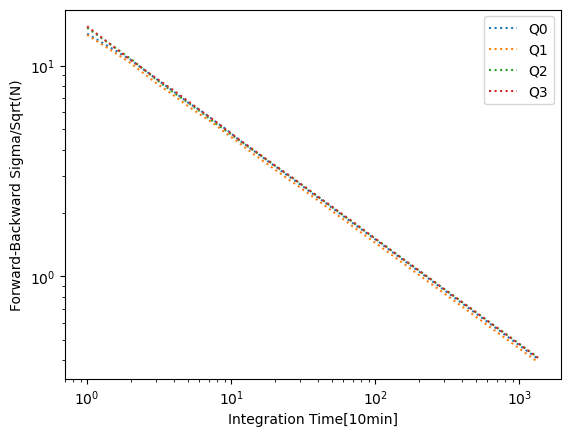

In [210]:
plt.loglog(stda[:,0],":",label="Q0")
plt.loglog(stda[:,1],":",label="Q1")
plt.loglog(stda[:,2],":",label='Q2')
plt.loglog(stda[:,3],":",label='Q3')
plt.ylabel("Forward-Backward Sigma/Sqrt(N)")
plt.xlabel("Integration Time[10min]")
plt.legend()
plt.savefig('renormalize_std_over_time')
plt.show()

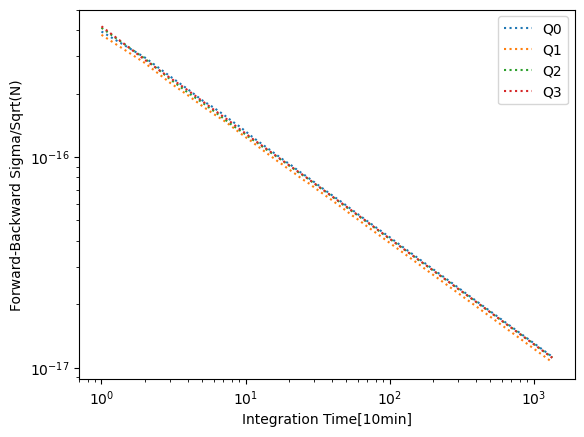

In [211]:
plt.loglog( (stda[:,0]/bb[0]/0.17/3e12),":",label="Q0")
plt.loglog((stda[:,1]/bb[3]/0.17/3e12),":",label="Q1")
plt.loglog((stda[:,2]/bb[3]/0.17/3e12),":",label='Q2')
plt.loglog((stda[:,3]/bb[3]/0.17/3e12),":",label='Q3')
plt.ylabel("Forward-Backward Sigma/Sqrt(N)")
plt.xlabel("Integration Time[10min]")
plt.legend()
plt.savefig('log_renormalize_std_over_time')
plt.show()

In [212]:
stda[-1,3]/bb[3]/0.17/3e12

np.float64(1.1117971113391339e-17)

In [294]:
i=100
np.std(fc[:60*i,:]-bc[:60*i,:] ,axis=0  )

array([350.36668124, 338.57851246, 347.90791526, 347.66398671])

(array([  6.,  58., 212., 518., 855., 904., 638., 310.,  87.,  12.]),
 array([63854. , 64018.2, 64182.4, 64346.6, 64510.8, 64675. , 64839.2,
        65003.4, 65167.6, 65331.8, 65496. ]),
 <BarContainer object of 10 artists>)

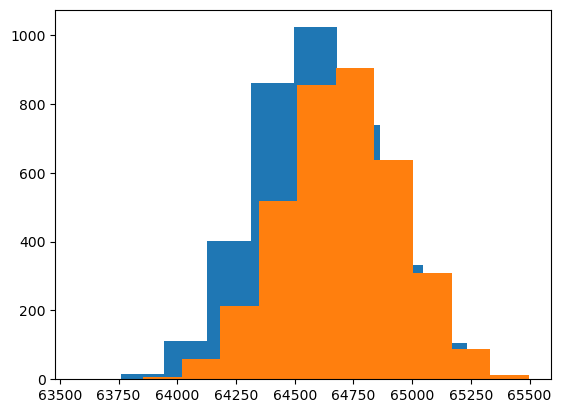

In [295]:
plt.hist(t_counts[findex,3])
plt.hist(t_counts[bindex,3])

In [296]:
np.mean()

TypeError: mean() missing 1 required positional argument: 'a'

## Config Files

In [7]:
# Find the related config files; 
find_calib_files_for_datafile(files[0])

{'data_file': '/data/share/data_20260318_173345.dat.31',
 'first_frame_time': datetime.datetime(2026, 3, 19, 23, 33, 59, 244802),
 'dark': '/data/dark/dark/dark_2D_1773986400.npy',
 'filter1': '/data/dark/filter/filter_1772533844.npy',
 'gain': '/data/gain/gain/gain_1773915924.npy',
 'filter2': '/data/gain/filter/filter_1773915924.npy'}

In [8]:
gain_file= find_calib_files_for_datafile(files[0])['gain']
gain = np.load(gain_file)

Text(0.5, 1.0, 'gain')

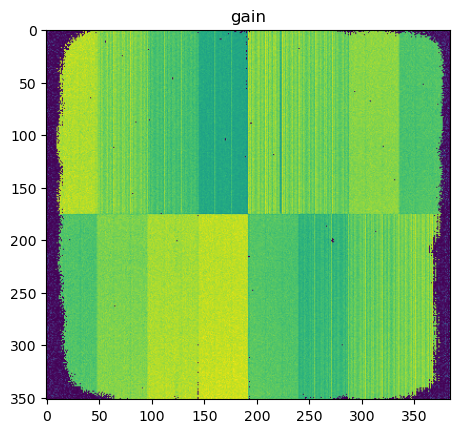

In [9]:
plt.imshow(epix.convert_image(gain))
plt.title("gain")

## Related Files

In [10]:
sfiles=find_files_in_range('/data/S2',start,end)

In [11]:
sdet= L2SpectrumDriver(sfiles[0])

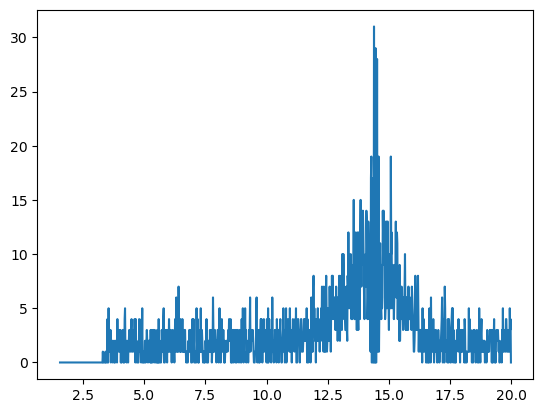

In [12]:
(energy,counts) = sdet.get_small_spec(frame)
plt.plot(energy[100:],counts[100:])

## SQL

In [13]:
sql=sql_writer()

In [14]:
times, values= get_values_in_timerange(sql, start, end, value_col="T")

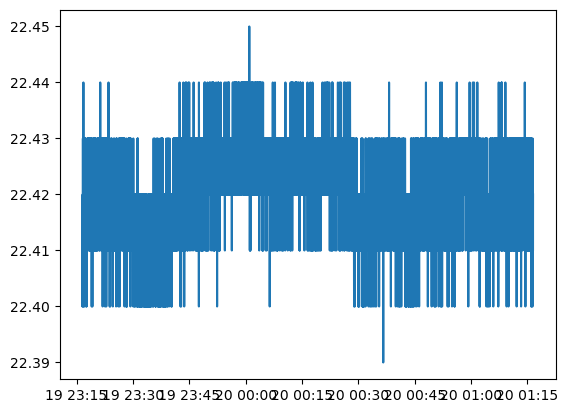

In [15]:
plt.plot(times,values)